# Mercado Imobiliário Brasileiro
## Análise de preços e comportamento entre 2015 e 2024
**Aluno:** Pedro Artur Brandão Murillo  
**Professor:** Alexandre Neves Louzada  
**Disciplina:** Linguagem de Programação: Análise e Visualização de Dados com Python  
**Avaliação:** G1

Como os preços dos imóveis se comportam na base simulada do mercado imobiliário brasileiro entre 2015 e 2024, considerando localização, características dos imóveis e indicadores econômicos?

Os registros são simulados e fornecidos para a atividade. As conclusões descrevem esta base, sem representar o mercado real ou uma amostra probabilística.

In [1]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sqlalchemy import create_engine, text
from IPython.display import display, Markdown

RAIZ = Path.cwd() if (Path.cwd() / 'dados').exists() else Path.cwd().parent
CSV = RAIZ / 'dados' / 'simulacao_mercado_imobiliario_brasil.csv'
hash_original = hashlib.sha256(CSV.read_bytes()).hexdigest()
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
def br(valor, casas=2):
    return f'{valor:,.{casas}f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
df = pd.read_csv(CSV)
display(df.shape, df.head())
df.info()
display(df.dtypes.to_frame('tipo'))

(4440, 16)

,ano,mes,data,regiao,uf,cidade,bairro,tipo_imovel,area_m2,quartos,vagas_garagem,preco_imovel,preco_m2,renda_media,taxa_juros,nivel_preco
0,2015,1,2015-01-01,Norte,AM,Manaus,Boa Vista,Casa,162,4,3,696835.01,3946.50,2069.62,13.92,Luxo
1,2015,1,2015-01-01,Norte,PA,Belém,Boa Vista,Studio,46,3,2,299378.31,9805.85,2977.65,11.10,Baixo
2,2015,1,2015-01-01,Norte,PA,Santarém,Centro,Cobertura,159,2,1,324224.24,17435.31,4546.93,11.88,Baixo
3,2015,1,2015-01-01,Norte,RO,Porto Velho,Boa Vista,Studio,104,4,2,149498.43,14149.33,4208.43,7.06,Médio
4,2015,1,2015-01-01,Norte,TO,Palmas,Boa Vista,Studio,182,0,3,283616.71,9447.97,2753.91,8.64,Baixo


<class 'pandas.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ano            4440 non-null   int64  
 1   mes            4440 non-null   int64  
 2   data           4440 non-null   str    
 3   regiao         4440 non-null   str    
 4   uf             4440 non-null   str    
 5   cidade         4440 non-null   str    
 6   bairro         4440 non-null   str    
 7   tipo_imovel    4440 non-null   str    
 8   area_m2        4440 non-null   int64  
 9   quartos        4440 non-null   int64  
 10  vagas_garagem  4440 non-null   int64  
 11  preco_imovel   4440 non-null   float64
 12  preco_m2       4440 non-null   float64
 13  renda_media    4440 non-null   float64
 14  taxa_juros     4440 non-null   float64
 15  nivel_preco    4440 non-null   str    
dtypes: float64(4), int64(5), str(7)
memory usage: 784.7 KB


,tipo
ano,int64
mes,int64
data,str
regiao,str
uf,str
cidade,str
bairro,str
tipo_imovel,str
area_m2,int64
quartos,int64


## Explicação da base
`ano`, `mes` e `data` identificam o período. `regiao`, `uf`, `cidade` e `bairro` descrevem a localização. `tipo_imovel`, `area_m2`, `quartos` e `vagas_garagem` caracterizam os imóveis. `preco_imovel` e `preco_m2` são indicadores de preço fornecidos. `renda_media` e `taxa_juros` são indicadores econômicos simulados. `nivel_preco` é uma categoria fornecida, sem escala quantitativa presumida.

In [2]:
df['data'] = pd.to_datetime(df['data'], errors='coerce')
resumo = {'registros': len(df), 'colunas_originais': len(df.columns),
          'inicio': str(df.data.min().date()), 'fim': str(df.data.max().date()),
          'meses': df.data.dt.to_period('M').nunique(), 'cidades': df.cidade.nunique(),
          'ufs': df.uf.nunique(), 'regioes': df.regiao.nunique()}
display(pd.Series(resumo, name='Base analisada'))
display(df.groupby('data').size().describe().to_frame('Registros por mês'))
assert df.shape == (4440, 16)
assert df.groupby(['data', 'cidade']).size().eq(1).all()
assert df.data.nunique() == 120
assert df.data.min() == pd.Timestamp('2015-01-01')
assert df.data.max() == pd.Timestamp('2024-12-01')

registros                  4440
colunas_originais            16
inicio               2015-01-01
fim                  2024-12-01
meses                       120
cidades                      37
ufs                          20
regioes                       5
Name: Base analisada, dtype: object

,Registros por mês
count,120.0
mean,37.0
std,0.0
min,37.0
25%,37.0
50%,37.0
75%,37.0
max,37.0


## Qualidade, limpeza e preparação
A validação precede qualquer alteração. Zero quartos ou vagas pode ser válido; preço, área e renda devem ser positivos. Juros não podem ser negativos. Não há remoção automática de valores extremos.

In [3]:
positivas = ['area_m2', 'preco_imovel', 'preco_m2', 'renda_media']
nao_negativas = ['quartos', 'vagas_garagem', 'taxa_juros']
qualidade = {'ausentes': int(df.isna().sum().sum()),
             'duplicatas': int(df.duplicated().sum()),
             'datas_invalidas': int(df.data.isna().sum()),
             'valores_nao_positivos': int(df[positivas].le(0).sum().sum()),
             'valores_negativos': int(df[nao_negativas].lt(0).sum().sum()),
             'periodos_inconsistentes': int(((df.ano != df.data.dt.year) | (df.mes != df.data.dt.month)).sum())}
display(pd.Series(qualidade))
categoricas = ['regiao', 'uf', 'cidade', 'bairro', 'tipo_imovel', 'nivel_preco']
for coluna in categoricas:
    display(pd.Series(sorted(df[coluna].unique()), name=coluna))
assert all(v == 0 for v in qualidade.values())
assert not any(df[c].str.strip().ne(df[c]).any() for c in categoricas)
assert df.groupby('cidade').uf.nunique().eq(1).all()
assert df.groupby('uf').regiao.nunique().eq(1).all()
display(df.describe().T)
q1, q3 = df.preco_imovel.quantile([0.25, 0.75])
iqr = q3 - q1
limite_inferior, limite_superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
extremos = (df.preco_imovel < limite_inferior) | (df.preco_imovel > limite_superior)
display(pd.Series({'Q1': q1, 'Q3': q3, 'IQR': iqr, 'limite_inferior': limite_inferior,
                  'limite_superior': limite_superior, 'outliers': int(extremos.sum()),
                  'percentual': extremos.mean() * 100}))
display(Markdown(f'Foram encontrados **{extremos.sum()} valores extremos ({br(extremos.mean()*100)}%)** pelo IQR. Todos foram mantidos: preços elevados são plausíveis e não há evidência suficiente de erro. Nenhuma linha foi removida; os testes de qualidade não encontraram registros inválidos.'))

ausentes                   0
duplicatas                 0
datas_invalidas            0
valores_nao_positivos      0
valores_negativos          0
periodos_inconsistentes    0
dtype: int64

0    Centro-Oeste
1        Nordeste
2           Norte
3         Sudeste
4             Sul
Name: regiao, dtype: str

0     AM
1     BA
2     CE
3     DF
4     ES
5     GO
6     MA
7     MG
8     MS
9     MT
10    PA
11    PB
12    PE
13    PR
14    RJ
15    RO
16    RS
17    SC
18    SP
19    TO
Name: uf, dtype: str

0        Aparecida de Goiânia
1              Belo Horizonte
2                       Belém
3                    Brasília
4                    Campinas
5                Campo Grande
6               Caxias do Sul
7                      Cuiabá
8                    Curitiba
9            Feira de Santana
10              Florianópolis
11                  Fortaleza
12                    Goiânia
13    Jaboatão dos Guararapes
14                  Joinville
15                João Pessoa
16          Juazeiro do Norte
17               Juiz de Fora
18                   Londrina
19                     Manaus
20                    Niterói
21                Nova Iguaçu
22                     Palmas
23                 Petrópolis
24               Porto Alegre
25                Porto Velho
26                     Recife
27             Ribeirão Preto
28             Rio de Janeiro
29                   Salvador
30                   Santarém
31                      Serra
32                   São Luís
33        

0         Boa Vista
1            Centro
2    Jardim América
3         Vila Nova
Name: bairro, dtype: str

0       Apartamento
1              Casa
2         Cobertura
3    Sala Comercial
4            Studio
Name: tipo_imovel, dtype: str

0     Alto
1    Baixo
2     Luxo
3    Médio
Name: nivel_preco, dtype: str

,count,mean,min,25%,50%,75%,max,std
ano,4440.0,2019.5,2015.0,2017.0,2019.5,2022.0,2024.0,2.872605
mes,4440.0,6.5,1.0,3.75,6.5,9.25,12.0,3.452441
data,4440,2019-12-16 10:48:00,2015-01-01 00:00:00,2017-06-23 12:00:00,2019-12-16 12:00:00,2022-06-08 12:00:00,2024-12-01 00:00:00,NaN
area_m2,4440.0,123.10045,30.0,76.0,121.0,171.0,219.0,54.962727
quartos,4440.0,1.955856,0.0,1.0,2.0,3.0,4.0,1.43582
vagas_garagem,4440.0,1.492793,0.0,0.0,2.0,2.0,3.0,1.124165
preco_imovel,4440.0,682299.262306,54674.54,339078.375,537645.22,857502.9725,6416335.58,532001.22107
preco_m2,4440.0,10861.723687,3519.52,7264.425,10968.15,14479.4125,17998.7,4192.914818
renda_media,4440.0,3498.048619,952.0,3012.7,3515.4,3975.5825,6341.42,706.411642
taxa_juros,4440.0,10.524473,7.0,8.73,10.52,12.31,14.0,2.042431


Q1                 3.390784e+05
Q3                 8.575030e+05
IQR                5.184246e+05
limite_inferior   -4.385585e+05
limite_superior    1.635140e+06
outliers           2.480000e+02
percentual         5.585586e+00
dtype: float64

Foram encontrados **248 valores extremos (5,59%)** pelo IQR. Todos foram mantidos: preços elevados são plausíveis e não há evidência suficiente de erro. Nenhuma linha foi removida; os testes de qualidade não encontraram registros inválidos.

## Auditoria de preço por m²
A razão calculada serve apenas para auditoria. O indicador fornecido permanece intacto no banco e no dashboard.

In [4]:
auditoria = df[['preco_imovel', 'area_m2', 'preco_m2']].copy()
auditoria['preco_m2_calculado'] = auditoria.preco_imovel / auditoria.area_m2
auditoria['diferenca_relativa'] = (auditoria.preco_m2_calculado - auditoria.preco_m2).abs() / auditoria.preco_m2
display(auditoria.head(), auditoria.describe().T)
corr_auditoria = auditoria[['preco_m2', 'preco_m2_calculado']].corr().iloc[0, 1]
coincidentes = int(np.isclose(auditoria.preco_m2, auditoria.preco_m2_calculado, atol=0.01, rtol=0).sum())
display(Markdown(f'A correlação entre o valor fornecido e a razão calculada é **{br(corr_auditoria, 4)}**; {coincidentes} registros coincidem com tolerância absoluta de R$ 0,01. A diferença relativa absoluta mediana é {br(auditoria.diferenca_relativa.median()*100)}%. Os campos não devem ser tratados como matematicamente equivalentes nesta simulação.'))

,preco_imovel,area_m2,preco_m2,preco_m2_calculado,diferenca_relativa
0,696835.01,162,3946.50,4301.450679,0.089941
1,299378.31,46,9805.85,6508.224130,0.336292
2,324224.24,159,17435.31,2039.146164,0.883045
3,149498.43,104,14149.33,1437.484904,0.898406
4,283616.71,182,9447.97,1558.333571,0.835062


,count,mean,std,min,25%,50%,75%,max
preco_imovel,4440.0,682299.262306,532001.221070,54674.540000,339078.375000,537645.220000,857502.972500,6.416336e+06
area_m2,4440.0,123.100450,54.962727,30.000000,76.000000,121.000000,171.000000,2.190000e+02
preco_m2,4440.0,10861.723687,4192.914818,3519.520000,7264.425000,10968.150000,14479.412500,1.799870e+04
preco_m2_calculado,4440.0,7251.851707,7786.857589,298.197614,2687.436969,4779.625687,8890.120669,1.060413e+05
diferenca_relativa,4440.0,0.712126,0.788186,0.000943,0.375371,0.636447,0.819286,1.216132e+01


A correlação entre o valor fornecido e a razão calculada é **-0,0175**; 0 registros coincidem com tolerância absoluta de R$ 0,01. A diferença relativa absoluta mediana é 63,64%. Os campos não devem ser tratados como matematicamente equivalentes nesta simulação.

## Engenharia de atributos e persistência
`ano_mes` permite agrupar e filtrar períodos. A coluna de auditoria não é persistida. SQLAlchemy cria a tabela SQLite e executa uma consulta de verificação.

In [5]:
df['ano_mes'] = df.data.dt.strftime('%Y-%m')
engine = create_engine(f"sqlite:///{(RAIZ / 'database' / 'mercado_imobiliario.sqlite').as_posix()}")
with engine.begin() as conexao:
    df.to_sql('mercado_imobiliario', conexao, if_exists='replace', index=False)
with engine.connect() as conexao:
    consulta = pd.read_sql(text('SELECT regiao, COUNT(*) AS registros, AVG(taxa_juros) AS juros_medios FROM mercado_imobiliario GROUP BY regiao'), conexao)
    total_banco = conexao.execute(text('SELECT COUNT(*) FROM mercado_imobiliario')).scalar_one()
display(consulta)
assert total_banco == len(df)
engine.dispose()

,regiao,registros,juros_medios
0,Centro-Oeste,600,10.613967
1,Nordeste,960,10.602542
2,Norte,600,10.495400
3,Sudeste,1560,10.471583
4,Sul,720,10.484625


## Análise exploratória e KPIs
As medianas reduzem a influência dos valores extremos. A taxa de juros é apresentada como média dos registros, sem assumir uma série econômica nacional.

preco_mediano       537645.220000
preco_m2_mediano     10968.150000
area_mediana           121.000000
juros_medios            10.524473
registros             4440.000000
dtype: float64

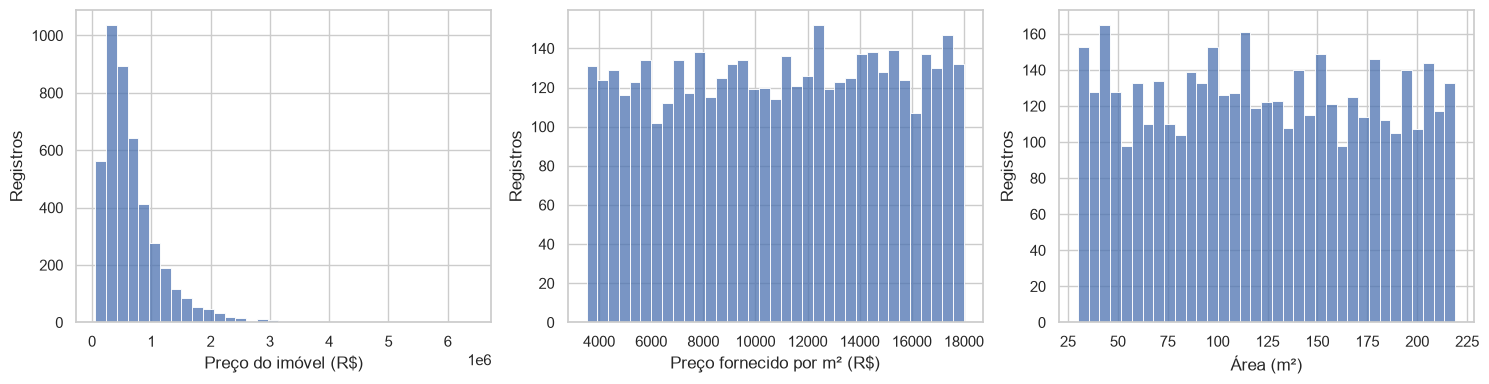

,preco_imovel,preco_m2
nivel_preco,,
Alto,547787.79,10756.130
Baixo,534500.94,11245.260
Luxo,535389.27,10833.585
Médio,530344.16,10992.730


A distribuição de preço do imóvel tem assimetria e valores extremos. As categorias de nível de preço são analisadas como rótulos da base, sem impor uma ordem monetária.

In [6]:
kpis = {'preco_mediano': df.preco_imovel.median(), 'preco_m2_mediano': df.preco_m2.median(),
        'area_mediana': df.area_m2.median(), 'juros_medios': df.taxa_juros.mean(), 'registros': len(df)}
display(pd.Series(kpis))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, coluna, titulo in zip(axes, ['preco_imovel', 'preco_m2', 'area_m2'], ['Preço do imóvel (R$)', 'Preço fornecido por m² (R$)', 'Área (m²)']):
    sns.histplot(data=df, x=coluna, bins=35, ax=ax)
    ax.set(xlabel=titulo, ylabel='Registros')
fig.tight_layout()
plt.show()
display(df.groupby('nivel_preco')[['preco_imovel', 'preco_m2']].median())
display(Markdown('A distribuição de preço do imóvel tem assimetria e valores extremos. As categorias de nível de preço são analisadas como rótulos da base, sem impor uma ordem monetária.'))

## Análise temporal
A mediana mensal é calculada antes da variação entre os extremos. A média móvel exige 12 meses completos; os primeiros 11 meses não possuem esse indicador. Valores nominais, sem ajuste de inflação.

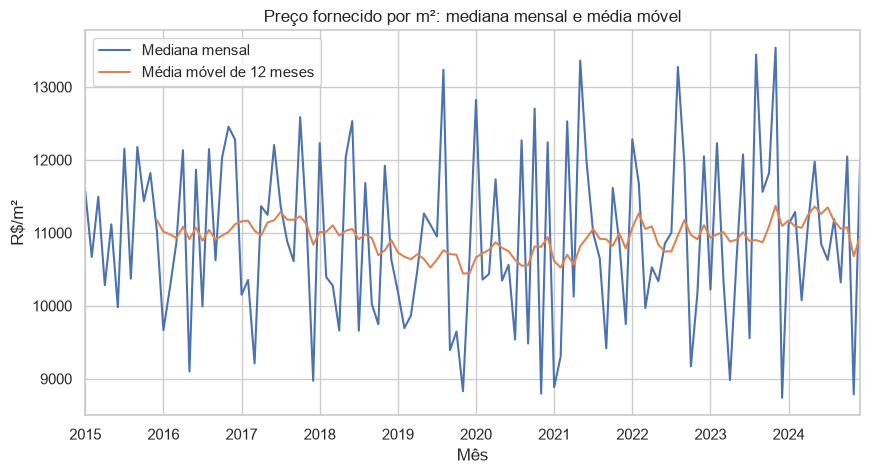

,mediana,media_movel_12
data,,
2015-01-01,11564.40,NaN
2024-12-01,12048.09,10955.818333


A mediana passou de R$ 11.564,40 para R$ 12.048,09, variação de 4,18%. Houve 58 aumentos e 61 quedas mensais. A comparação dos extremos não demonstra valorização contínua.

In [7]:
mensal = df.groupby('data').preco_m2.median().sort_index().to_frame('mediana')
mensal['media_movel_12'] = mensal.mediana.rolling(12, min_periods=12).mean()
variacao = (mensal.mediana.iloc[-1] / mensal.mediana.iloc[0] - 1) * 100
fig, ax = plt.subplots()
mensal.plot(ax=ax)
ax.set(title='Preço fornecido por m²: mediana mensal e média móvel', xlabel='Mês', ylabel='R$/m²')
ax.legend(['Mediana mensal', 'Média móvel de 12 meses'])
plt.show()
display(mensal.iloc[[0, -1]])
altas = int(mensal.mediana.diff().gt(0).sum())
quedas = int(mensal.mediana.diff().lt(0).sum())
display(Markdown(f'A mediana passou de R$ {br(mensal.mediana.iloc[0])} para R$ {br(mensal.mediana.iloc[-1])}, variação de {br(variacao)}%. Houve {altas} aumentos e {quedas} quedas mensais. A comparação dos extremos não demonstra valorização contínua.'))

## Análise geográfica
São comparadas as cinco regiões e somente as UFs presentes. A base não cobre os 27 estados e Distrito Federal. A quantidade de cidades por região também difere.

,preco_m2_mediano,registros
regiao,,
Centro-Oeste,11370.005,600
Sudeste,11117.060,1560
Nordeste,10779.400,960
Sul,10751.000,720
Norte,10743.740,600


,preco_m2_mediano,registros
uf,,
MA,12159.470,120
MS,11953.370,120
MT,11470.415,120
RJ,11412.835,480
GO,11395.340,240
MG,11319.670,360
ES,11133.295,360
DF,11038.695,120
RO,11020.430,120


,preco_m2_mediano,registros
cidade,,
Petrópolis,12237.870,120
São Luís,12159.470,120
Curitiba,12015.190,120
Campo Grande,11953.370,120
Juiz de Fora,11806.045,120
Belo Horizonte,11713.530,120
Aparecida de Goiânia,11560.965,120
Cuiabá,11470.415,120
Rio de Janeiro,11442.695,120


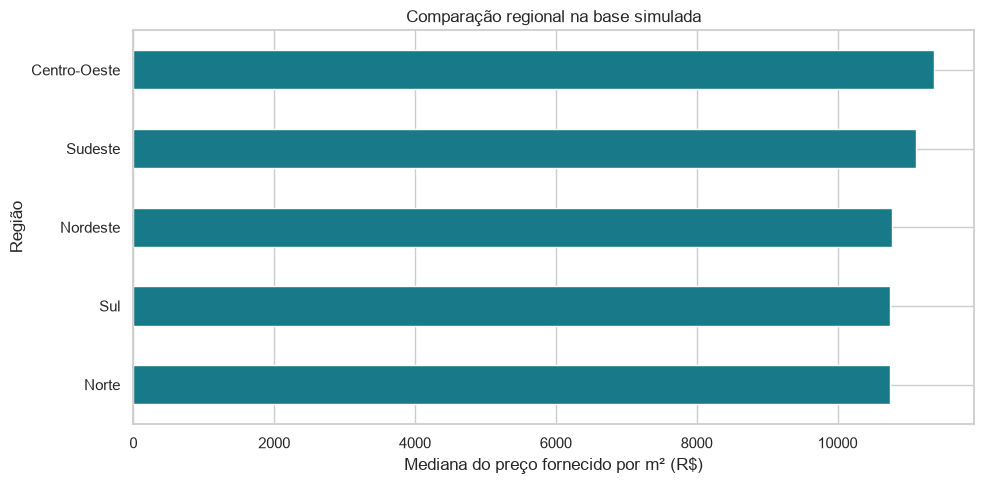

A maior mediana regional é de Centro-Oeste, com R$ 11.370,01/m². Entre as cidades, Petrópolis apresenta a maior mediana. As diferenças descrevem os registros simulados e não rankings do mercado real.

In [8]:
geografia = {}
for coluna in ['regiao', 'uf', 'cidade']:
    tabela = df.groupby(coluna).agg(preco_m2_mediano=('preco_m2', 'median'), registros=('preco_m2', 'size')).sort_values('preco_m2_mediano', ascending=False)
    geografia[coluna] = tabela
    display(tabela)
fig, ax = plt.subplots(figsize=(10, 5))
geografia['regiao'].preco_m2_mediano.sort_values().plot.barh(ax=ax, color='#187a89')
ax.set(xlabel='Mediana do preço fornecido por m² (R$)', ylabel='Região', title='Comparação regional na base simulada')
plt.tight_layout()
plt.show()
display(Markdown(f"A maior mediana regional é de {geografia['regiao'].index[0]}, com R$ {br(geografia['regiao'].iloc[0,0])}/m². Entre as cidades, {geografia['cidade'].index[0]} apresenta a maior mediana. As diferenças descrevem os registros simulados e não rankings do mercado real."))

## Perfil dos imóveis
A comparação considera tipos, área, quartos e vagas. As características não são necessariamente coerentes com as tipologias por se tratar de simulação.

,preco_imovel,preco_m2,area_m2,quartos,vagas_garagem
tipo_imovel,,,,,
Apartamento,550529.720,10834.060,122.0,2.0,2.0
Casa,524079.650,11037.470,121.0,2.0,1.0
Cobertura,536330.390,11290.200,122.0,2.0,1.0
Sala Comercial,547787.790,10978.395,119.0,2.0,2.0
Studio,534395.845,10686.440,123.0,2.0,2.0


,registros,preco_mediano,area_mediana
quartos,,,
0,956,552418.950,117.0
1,914,546035.130,125.0
2,836,520898.460,121.5
3,838,548557.715,120.0
4,896,517746.470,126.0


,registros,preco_mediano,area_mediana
vagas_garagem,,,
0,1146,560024.030,118.5
1,1064,521183.825,121.5
2,1126,552402.855,125.0
3,1104,513780.360,121.5


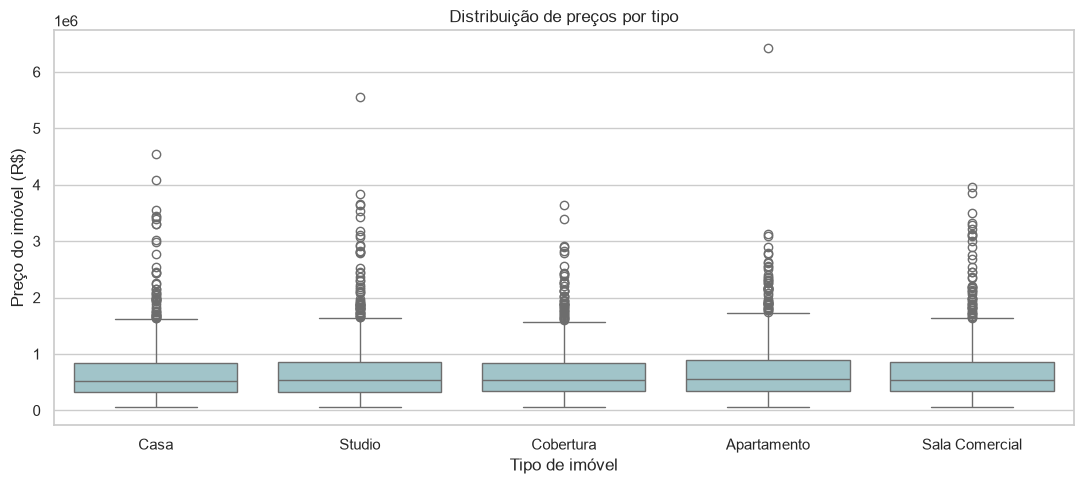

Há dispersão de preços dentro de cada tipo. A distribuição não permite atribuir um preço apenas ao número de quartos, vagas ou à área.

In [9]:
display(df.groupby('tipo_imovel')[['preco_imovel', 'preco_m2', 'area_m2', 'quartos', 'vagas_garagem']].median())
for coluna in ['quartos', 'vagas_garagem']:
    display(df.groupby(coluna).agg(registros=('preco_imovel','size'), preco_mediano=('preco_imovel','median'), area_mediana=('area_m2','median')))
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x='tipo_imovel', y='preco_imovel', ax=ax, color='#9bc9cf')
ax.set(xlabel='Tipo de imóvel', ylabel='Preço do imóvel (R$)', title='Distribuição de preços por tipo')
plt.tight_layout()
plt.show()
grafico = px.scatter(df, x='area_m2', y='preco_imovel', color='tipo_imovel', hover_data=['cidade'], title='Área e preço dos imóveis', labels={'area_m2': 'Área (m²)', 'preco_imovel': 'Preço (R$)', 'tipo_imovel':'Tipo'})
display(grafico)
display(Markdown('Há dispersão de preços dentro de cada tipo. A distribuição não permite atribuir um preço apenas ao número de quartos, vagas ou à área.'))

## Correlação estatística
Correlação de Pearson mede associação linear, sem estabelecer causalidade. A diagonal é excluída ao procurar a associação de maior magnitude.

,area_m2,quartos,vagas_garagem,preco_imovel,preco_m2,renda_media,taxa_juros
area_m2,1.000000,0.009625,0.023674,0.032302,-0.002556,0.013090,-0.003788
quartos,0.009625,1.000000,0.031066,-0.012185,-0.010186,-0.003368,-0.012864
vagas_garagem,0.023674,0.031066,1.000000,-0.019848,0.002866,-0.033697,0.007602
preco_imovel,0.032302,-0.012185,-0.019848,1.000000,-0.015442,-0.010958,0.002018
preco_m2,-0.002556,-0.010186,0.002866,-0.015442,1.000000,0.002762,0.004572
renda_media,0.013090,-0.003368,-0.033697,-0.010958,0.002762,1.000000,-0.012157
taxa_juros,-0.003788,-0.012864,0.007602,0.002018,0.004572,-0.012157,1.000000


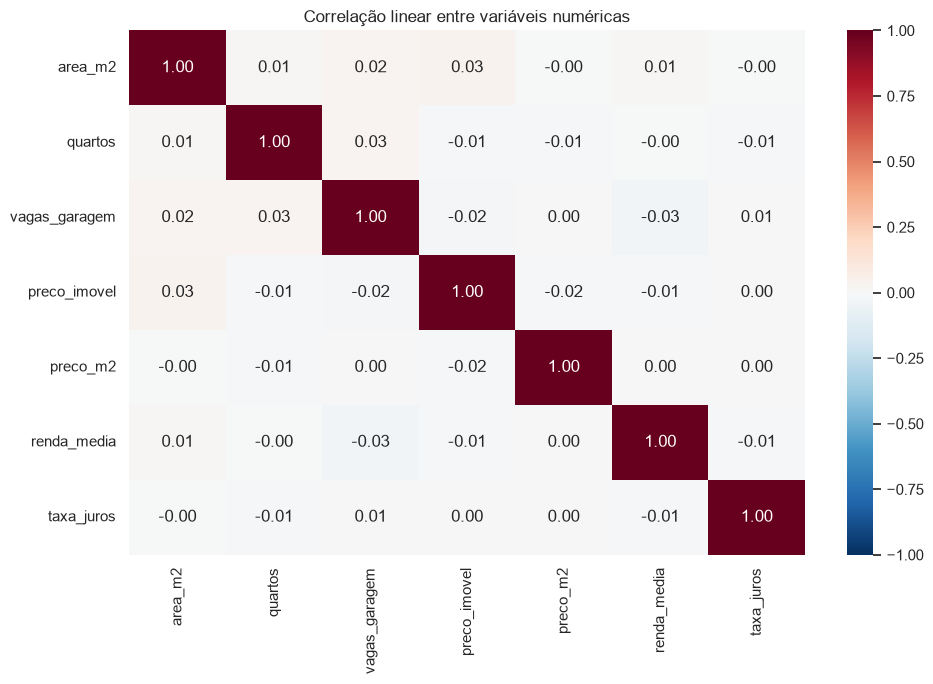

A maior correlação absoluta é entre vagas_garagem e renda_media: -0,0337. As associações lineares observadas são fracas. Isso não descarta relações não lineares nem demonstra causalidade.

In [10]:
numericas = ['area_m2', 'quartos', 'vagas_garagem', 'preco_imovel', 'preco_m2', 'renda_media', 'taxa_juros']
correlacao = df[numericas].corr()
display(correlacao)
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, center=0, ax=ax)
ax.set_title('Correlação linear entre variáveis numéricas')
plt.tight_layout()
plt.show()
pares = correlacao.where(np.triu(np.ones(correlacao.shape), k=1).astype(bool)).stack()
par = pares.abs().idxmax()
maior_corr = float(pares.loc[par])
display(Markdown(f'A maior correlação absoluta é entre {par[0]} e {par[1]}: {br(maior_corr, 4)}. As associações lineares observadas são fracas. Isso não descarta relações não lineares nem demonstra causalidade.'))

## Interpretação e conclusão

In [11]:
display(Markdown(f"""O preço mediano do imóvel é **R$ {br(kpis['preco_mediano'])}**, e o preço fornecido por m² tem mediana de **R$ {br(kpis['preco_m2_mediano'])}**. A área mediana é {br(kpis['area_mediana'],0)} m² e a taxa média de juros é {br(kpis['juros_medios'])}%.

A série mensal oscila, com variação de {br(variacao)}% entre janeiro de 2015 e dezembro de 2024. A comparação geográfica e por perfil mostra diferenças nos registros, mas as correlações lineares são fracas. Os {extremos.sum()} valores extremos foram preservados.

A cobertura se limita a {resumo['cidades']} cidades e {resumo['ufs']} UFs. O preço por m² fornecido diverge da razão entre preço e área. Não há ajuste inflacionário, acompanhamento de imóveis individuais ou evidência causal. Os resultados não devem ser extrapolados para o mercado imobiliário brasileiro real."""))
assert hashlib.sha256(CSV.read_bytes()).hexdigest() == hash_original
resultados = dict(resumo, **kpis, outliers=int(extremos.sum()), percentual_outliers=float(extremos.mean()*100),
                  variacao=float(variacao), inicio_m2=float(mensal.mediana.iloc[0]), fim_m2=float(mensal.mediana.iloc[-1]),
                  maior_correlacao=maior_corr, par_correlacao=list(par), correlacao_auditoria=float(corr_auditoria),
                  diferenca_auditoria=float(auditoria.diferenca_relativa.median()*100),
                  regiao_maior=geografia['regiao'].index[0], cidade_maior=geografia['cidade'].index[0],
                  hash_csv=hash_original)
# Resultados para conferir a documentação durante a execução local.
print(json.dumps(resultados, ensure_ascii=False, indent=2))

O preço mediano do imóvel é **R$ 537.645,22**, e o preço fornecido por m² tem mediana de **R$ 10.968,15**. A área mediana é 121 m² e a taxa média de juros é 10,52%.

A série mensal oscila, com variação de 4,18% entre janeiro de 2015 e dezembro de 2024. A comparação geográfica e por perfil mostra diferenças nos registros, mas as correlações lineares são fracas. Os 248 valores extremos foram preservados.

A cobertura se limita a 37 cidades e 20 UFs. O preço por m² fornecido diverge da razão entre preço e área. Não há ajuste inflacionário, acompanhamento de imóveis individuais ou evidência causal. Os resultados não devem ser extrapolados para o mercado imobiliário brasileiro real.

{
  "registros": 4440,
  "colunas_originais": 16,
  "inicio": "2015-01-01",
  "fim": "2024-12-01",
  "meses": 120,
  "cidades": 37,
  "ufs": 20,
  "regioes": 5,
  "preco_mediano": 537645.22,
  "preco_m2_mediano": 10968.15,
  "area_mediana": 121.0,
  "juros_medios": 10.524472972972973,
  "outliers": 248,
  "percentual_outliers": 5.585585585585585,
  "variacao": 4.182577565632473,
  "inicio_m2": 11564.4,
  "fim_m2": 12048.09,
  "maior_correlacao": -0.03369685507456567,
  "par_correlacao": [
    "vagas_garagem",
    "renda_media"
  ],
  "correlacao_auditoria": -0.017510573856702842,
  "diferenca_auditoria": 63.644701081021246,
  "regiao_maior": "Centro-Oeste",
  "cidade_maior": "Petrópolis",
  "hash_csv": "2c6a681559b59dd6002e97df45af14cb275c48076c9971ab335de1f5c19cd3fb"
}
